4) Recurrent neural network (RNN) Use the Google stock prices dataset and design a time 
series analysis and prediction system using RNN. 

Epoch 1/20


c:\Users\yuvra\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 0.4377 - mae: 0.6112 - mse: 0.4377
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.1427 - mae: 0.3305 - mse: 0.1427
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0438 - mae: 0.1811 - mse: 0.0438 
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0588 - mae: 0.1848 - mse: 0.0588
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0812 - mae: 0.2319 - mse: 0.0812
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0616 - mae: 0.1949 - mse: 0.0616
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0378 - mae: 0.1395 - mse: 0.0378
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0301 - mae: 0.1411 - mse: 0.0301
Epoch 9/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0327 - mae: 0.1537 - mse: 0.0327
Epoch 10/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0362 - mae: 0.1639 - mse: 0.0362
Epoch 11/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0347 - mae: 0.1605 - mse: 0.0

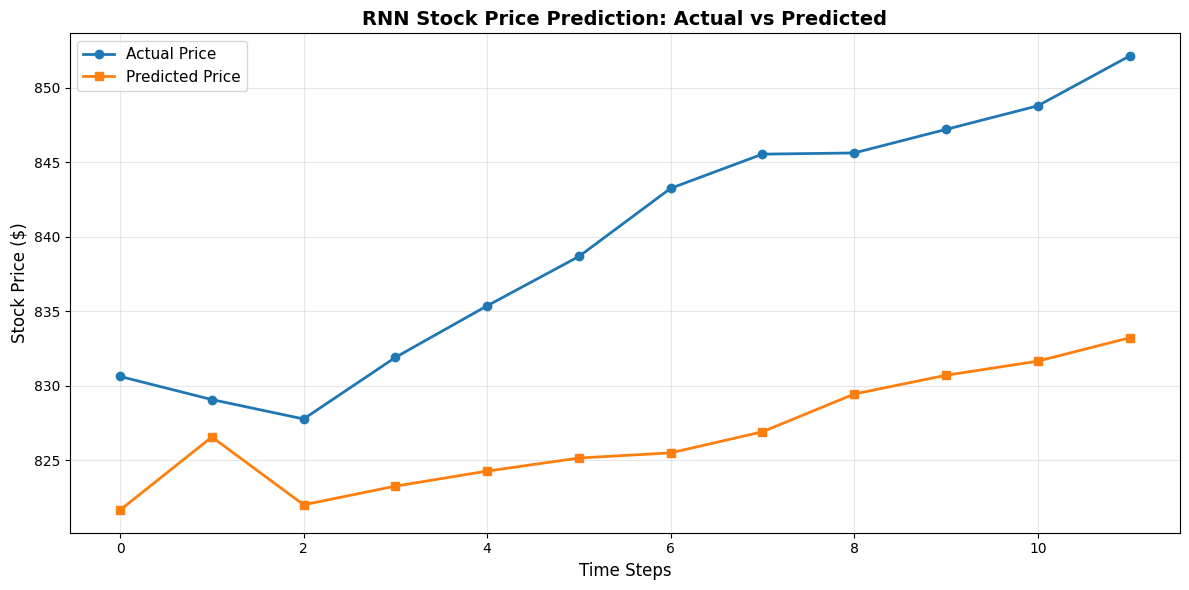


✓ Graph plotted successfully


In [ ]:
# ---------------------------------------------------
# Recurrent Neural Network (RNN)
# Google Stock Price Prediction
# ---------------------------------------------------

# Import Libraries
import pandas as pd
import numpy as np

# Scaling
from sklearn.preprocessing import MinMaxScaler

# Metrics
from sklearn.metrics import *

# TensorFlow RNN Libraries
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *

# ---------------------------------------------------
# STEP 1 : Load Dataset
# ---------------------------------------------------

# Read Google Stock dataset
data = pd.read_csv("goog.csv")

# ---------------------------------------------------
# STEP 2 : Use Closing Prices
# ---------------------------------------------------

# Extract Close column

prices = data['Close'].values.reshape(-1,1)

# ---------------------------------------------------
# STEP 3 : Normalize Data
# ---------------------------------------------------

# Scale values between 0 and 1

scaler = MinMaxScaler()

prices = scaler.fit_transform(prices)

# ---------------------------------------------------
# STEP 4 : Create Sequences
# ---------------------------------------------------

# Use previous 5 days
# to predict next day

X=[]
y=[]

for i in range(5,len(prices)):

    X.append(prices[i-5:i])

    y.append(prices[i])

X=np.array(X)
y=np.array(y)

# ---------------------------------------------------
# STEP 5 : Split Dataset
# ---------------------------------------------------

# 80% -> Training
# 20% -> Testing

split = int(0.8*len(X))

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

# ---------------------------------------------------
# STEP 6 : Build RNN Model
# ---------------------------------------------------

model = Sequential([

    # RNN Layer
    SimpleRNN(

        50,

        activation='tanh',

        input_shape=(5,1)
    ),

    # Output Layer
    Dense(1)
])

# ---------------------------------------------------
# STEP 7 : Compile Model
# ---------------------------------------------------

model.compile(

    optimizer='adam',

    # Regression Loss
    loss='mse',

    metrics=['mae']
)

# ---------------------------------------------------
# STEP 8 : Train Model
# ---------------------------------------------------

model.fit(

    X_train,
    y_train,

    epochs=20,
    batch_size=16,

    verbose=1
)

# ---------------------------------------------------
# STEP 9 : Evaluate Model
# ---------------------------------------------------

loss,mae = model.evaluate(

    X_test,
    y_test,

    verbose=0
)

print("\nMODEL EVALUATION\n")

print("Loss =",loss)
print("MAE =",mae)

# ---------------------------------------------------
# STEP 10 : Additional Metrics
# ---------------------------------------------------

# Predictions
y_pred = model.predict(X_test,verbose=0)

# Convert back to original values
y_test = scaler.inverse_transform(y_test)
y_pred = scaler.inverse_transform(y_pred)

# RMSE
rmse = np.sqrt(
    mean_squared_error(y_test,y_pred)
)

# R2 Score
r2 = r2_score(y_test,y_pred)

print("RMSE =",rmse)
print("R2 Score =",r2)

# ---------------------------------------------------
# METRICS EXPLANATION
# ---------------------------------------------------

# MSE  -> Mean Squared Error
# MAE  -> Mean Absolute Error
# RMSE -> Root Mean Squared Error
# R2   -> Regression Accuracy

# ---------------------------------------------------
# STEP 11 : Stock Price Predictions
# ---------------------------------------------------

print("\nStock Price Predictions:\n")

for i in range(5):

    print(

        "Actual =",

        round(y_test[i][0],2),

        "Predicted =",

        round(y_pred[i][0],2)
    )